# Automatic Game Balancing with Top Trumps

In [1]:
import random
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import rankdata

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.lhs import LHS
from pymoo.termination import get_termination

## Top Trumps Implementation

In [2]:
class TopTrumpsSimulation:
    """TopTrumpsSimulation implements the basic TopTrumps game engine and agent-based simulation."""

    def __init__(self, num_cards=52, num_categories=6):
        self.K = num_cards  # Number of cards
        self.L = num_categories  # Number of categories

        self.set_random_deck()

    def _normalize_deck(self, deck):
        """Normalizes the deck such that each property is in the range [0,1]. This is required for the p0 agent."""
        min_values = [0] * self.L
        max_values = [0] * self.L

        for cat in range(self.L):
            all_values = [card[cat] for card in deck]
            min_values[cat] = min(all_values)
            max_values[cat] = max(all_values)

        normalized_deck = []

        for card in deck:
            normalized_card = [0] * self.L
            for cat in range(self.L):
                normalized_card[cat] = (card[cat] - min_values[cat]) / (max_values[cat] - min_values[cat])
            normalized_deck.append(normalized_card)

        return normalized_deck

    def set_deck(self, deck_list):
        """Creates a deck from deck_list of length K*L."""

        assert len(deck_list) == self.K * self.L

        deck = np.array_split(deck_list, self.K)

        self.deck = deck
        self._normalized_deck = self._normalize_deck(deck)

    def set_random_deck(self, value_range = (1, 10)):
        """Generates a random deck with values in value_range."""
        deck_list = np.random.uniform(value_range[0], value_range[1], self.K * self.L)
        self.set_deck(deck_list)

    def get_p0_choice(self, card):
        """p0 assumes uniform distribution between max and min values per property and then picks the best value on current card."""
        return card.index(max(card))

    def get_p4_choice(self, card, remaining_cards):
        """p4 calculates exact win probability based on remaining cards."""
        best_prob = -1
        best_cat = 0

        for cat_idx in range(self.L):
            my_val = card[cat_idx]
            # Count how many cards in the potential card pool have a lower value
            wins = sum(1 for opp_card in remaining_cards if my_val > opp_card[cat_idx])
            prob = wins / len(remaining_cards)

            if prob > best_prob:
                best_prob = prob
                best_cat = cat_idx
        # print(f"Best prob: {best_prob:.2f}, cat: {best_cat}")
        return best_cat

    def simulate_game(self):
        # Shuffle and distribute cards
        temp_deck = list(self._normalized_deck)
        random.shuffle(temp_deck)

        # p4 vs p0 setup
        p4_hand = temp_deck[:self.K//2]
        p0_hand = temp_deck[self.K//2:]

        # Track unplayed cards remaining in the 'unplayed' pool for p4's knowledge 
        all_unplayed = list(temp_deck) 

        p4_tricks = 0
        current_turn = random.choice(['p4', 'p0']) # Random starting player
        trick_changes = 0

        # Game ends after all cards played once
        for i in range(self.K // 2):
            card_p4 = p4_hand[i]
            card_p0 = p0_hand[i]

            # Category Selection
            if current_turn == 'p4':
                category = self.get_p4_choice(card_p4, all_unplayed)
            else:
                category = self.get_p0_choice(card_p0)

            # Determine Round Winner
            val_p4 = card_p4[category]
            val_p0 = card_p0[category]

            # Remove current p0, p4 card from p4's tracking memory
            all_unplayed.remove(card_p0)
            all_unplayed.remove(card_p4)

            if val_p4 > val_p0:
                # print("P4 wins!")
                p4_tricks += 1
                if current_turn == 'p0':
                    current_turn = 'p4'
                    trick_changes += 1
            elif val_p0 > val_p4:
                # print("P0 wins!")
                if current_turn == 'p4':
                    current_turn = 'p0'
                    trick_changes += 1
            # In case of draw, current player keeps the lead

        return {
            "p4_tricks": p4_tricks,
            "trick_changes": trick_changes,
            "p4_won": p4_tricks > (self.K / 4) # p4 wins if they got more than half the tricks
        }

## Pymoo connection

TopTrumpsBalancing provides a pymoo-compatible interface for TopTrumpsSimulation. Note that the objectives are already negated to result in a minimization problem!

In [3]:
class TopTrumpsBalancing(ElementwiseProblem):
    """TopTrumpsBalancing connects TopTrumpsSimulation with the pymoo interface ElementwiseProblem."""

    def __init__(self, sim_instance, n_simulations):
        self.sim = sim_instance
        self.n_simulations = n_simulations
        
        # KL variables: Number of cards (K) * Categories (L) 
        n_var = self.sim.K * self.sim.L
        
        super().__init__(n_var=n_var,
                         n_obj=2, # Objectives: Fairness (p4 win rate) and Excitement (# trick changes)
                         n_constr=0,
                         xl=1.0, # Lower bound for values
                         xu=10.0) # Upper bound for values

    def _evaluate(self, x, out, *args, **kwargs):
        # Update simulation with the current candidate deck
        self.sim.set_deck(x)
        
        win_rates = []
        trick_changes_list = []
        
        # Perform multiple simulations to get an average
        for _ in range(self.n_simulations):
            res = self.sim.simulate_game()
            win_rates.append(1 if res['p4_won'] else 0)
            trick_changes_list.append(res['trick_changes'])
        
        # Objectives (Minimization):
        # f1: -Average Win Rate of p4 (Fairness)
        # f2: -Average Trick Changes (Excitement)
        out["F"] = [
            -np.mean(win_rates), 
            -np.mean(trick_changes_list)
        ]

Set up simulation and problem instance:

In [4]:
my_sim = TopTrumpsSimulation(num_cards=22, num_categories=4)
problem = TopTrumpsBalancing(my_sim, n_simulations=1000)

Now it's your turn: Optimize `problem` using an approach of your choice and analyze the results. Please refer to the documentation of [pymoo](https://pymoo.org) for more details. A good starting point is: <https://pymoo.org/getting_started/part_2.html#Initialize-an-Algorithm>

## Pareto Front Optimization

We use NSGA-II (Non-dominated Sorting Genetic Algorithm II) to approximate the Pareto front. Key configuration choices:

- **Latin Hypercube Sampling (LHS)**: Provides better initial coverage of the search space compared to random sampling
- **Population size = 100**: Larger populations maintain more diversity and find better Pareto fronts
- **Offspring = 50**: More offspring per generation increases exploration
- **SBX crossover (eta=10)**: Lower eta values create more diverse offspring (more exploration)
- **Polynomial mutation (eta=15, prob=1/n_var)**: Adaptive mutation rate based on problem dimensionality
- **200 generations**: More generations allow the algorithm to converge to a better approximation

In [5]:
# Configure NSGA-II with optimized parameters
algorithm = NSGA2(
    pop_size=100,
    n_offsprings=50,
    sampling=LHS(),
    crossover=SBX(prob=0.9, eta=10),
    mutation=PM(eta=15, prob=1.0/problem.n_var),
    eliminate_duplicates=True
)

# Termination criterion
termination = get_termination("n_gen", 200)

# Run optimization
result = minimize(
    problem,
    algorithm,
    termination,
    seed=42,
    save_history=True,  # Save history for later analysis
    verbose=True
)

# Store results for easy access
X = result.X  # Decision variables (deck configurations)
F = result.F  # Objective values

print(f"Number of solutions on Pareto front: {len(F)}")

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      4 |             - |             -
     2 |      150 |      6 |  0.1612903226 |         ideal
     3 |      200 |      6 |  0.0310786106 |         ideal
     4 |      250 |      4 |  0.1086956522 |         ideal
     5 |      300 |      5 |  0.1873111782 |         ideal
     6 |      350 |      8 |  0.2295081967 |         ideal
     7 |      400 |      6 |  0.2375000000 |         ideal
     8 |      450 |      7 |  0.0243902439 |         ideal
     9 |      500 |      7 |  0.1111111111 |         ideal
    10 |      550 |      3 |  0.2159383033 |         ideal
    11 |      600 |      5 |  0.2566371681 |         ideal
    12 |      650 |      4 |  0.1101973684 |         ideal
    13 |      700 |      5 |  0.0396470575 |             f
    14 |      750 |      5 |  0.000000E+00 |             f
    15 |      800 |      5 |  0.1198219803 |             f
    16 |      850 |      8 |  0.1038961039 |         ide

## Pareto Front Visualization

The Pareto front shows the trade-off between our two objectives:
- **Fairness**: The win rate of the skilled player (p4). Higher is better (skill should be rewarded).
- **Excitement**: Average number of trick changes per game. Higher means more back-and-forth gameplay.

Since pymoo minimizes objectives, we negated them in the problem definition. Here we negate them back for intuitive display (higher = better).

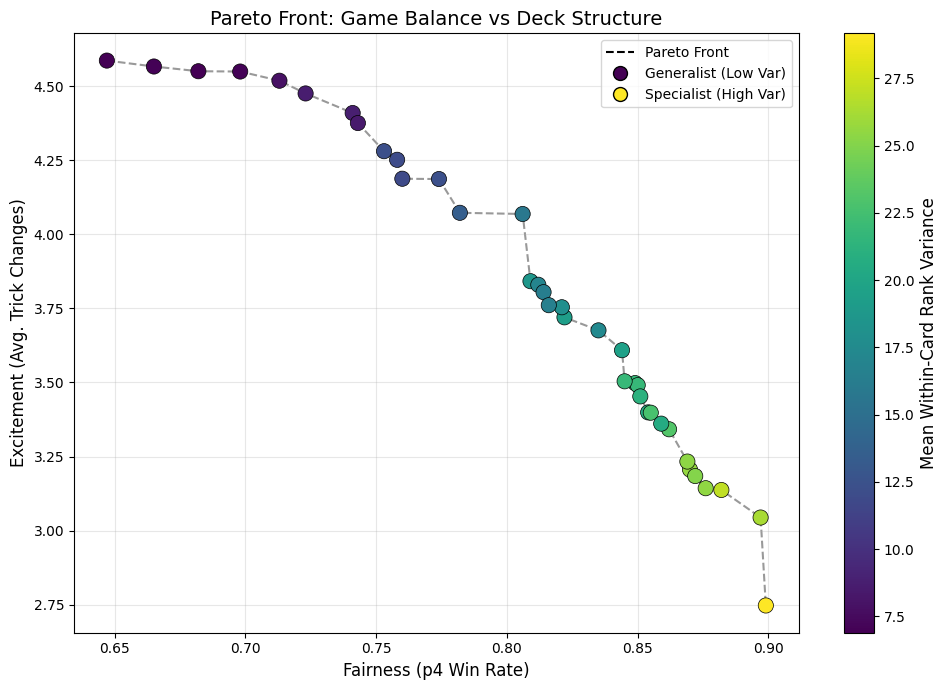

In [6]:
# Container for the variance metric
variances = []

for i in range(len(X)):
    # Reshape the flat solution back to (Cards, Categories)
    deck_matrix = np.array(X[i]).reshape(problem.sim.K, problem.sim.L)
    ranked_matrix = np.zeros_like(deck_matrix)
    
    # Rank values within each category (column) to normalize scales
    for cat in range(problem.sim.L):
        ranked_matrix[:, cat] = rankdata(deck_matrix[:, cat], method='average')
        
    # Calculate variance for each card (row), then average across the deck
    # High variance = Specialist (High stats in some cats, low in others)
    # Low variance = Generalist (Balanced stats across categories)
    card_variances = np.var(ranked_matrix, axis=1)
    variances.append(np.mean(card_variances))

variances = np.array(variances)

# Negate objectives back to maximization context
pareto_fairness = -F[:, 0]    # x-axis (p4 win rate)
pareto_excitement = -F[:, 1]  # y-axis (trick changes)

# Sort indices by fairness for the line plot and printing
sorted_idx = np.argsort(pareto_fairness)

# --- 3. Generate the Plot ---

fig, ax = plt.subplots(figsize=(10, 7))

# Define Colormap
cmap = plt.colormaps['viridis']

# Scatter Plot (Colored by Variance)
scatter = ax.scatter(pareto_fairness, pareto_excitement, 
                     c=variances, cmap=cmap, 
                     s=120, edgecolors='black', linewidth=0.5, zorder=2)

# Line Plot (Connecting the front)
ax.plot(pareto_fairness[sorted_idx], pareto_excitement[sorted_idx], 
        'k--', alpha=0.4, linewidth=1.5, zorder=1)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Mean Within-Card Rank Variance', fontsize=12)

# --- Custom Legend with Icons ---
# We create manual handles to explain the color meaning clearly
legend_handles = [
    # The Line
    mlines.Line2D([], [], color='black', linestyle='--', label='Pareto Front'),
    # Purple Circle (Low Variance)
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor=cmap(0.0), 
                  markersize=10, markeredgecolor='black', label='Generalist (Low Var)'),
    # Yellow Circle (High Variance)
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor=cmap(1.0), 
                  markersize=10, markeredgecolor='black', label='Specialist (High Var)')
]

ax.legend(handles=legend_handles, loc='best', fontsize=10, frameon=True)

# Formatting
ax.set_xlabel('Fairness (p4 Win Rate)', fontsize=12)
ax.set_ylabel('Excitement (Avg. Trick Changes)', fontsize=12)
ax.set_title('Pareto Front: Game Balance vs Deck Structure', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/pareto_front_top_trumps.svg")
plt.show()

In [7]:
print(f"\nPareto Front Statistics:")
print(f"  Fairness range: {pareto_fairness.min():.3f} - {pareto_fairness.max():.3f}")
print(f"  Excitement range: {pareto_excitement.min():.3f} - {pareto_excitement.max():.3f}")


Pareto Front Statistics:
  Fairness range: 0.647 - 0.899
  Excitement range: 2.747 - 4.587


## Parameter Sensitivity Analysis

An important question is how the game parameters affect the achievable trade-offs:
- **K (number of cards)**: More cards increase game length and potentially the search space
- **L (number of categories)**: More categories give players more strategic choices

We investigate how varying these parameters changes the shape and position of the Pareto front.

In [8]:
def run_optimization(K, L, n_gen=100, n_sim=1000, seed=42):
    """
    Helper function to run optimization for given K and L parameters.
    
    Parameters:
    -----------
    K : int - Number of cards
    L : int - Number of categories
    n_gen : int - Number of generations
    n_sim : int - Number of simulations per evaluation
    seed : int - Random seed
    
    Returns:
    --------
    result : pymoo Result object
    """
    sim = TopTrumpsSimulation(num_cards=K, num_categories=L)
    prob = TopTrumpsBalancing(sim, n_simulations=n_sim)
    
    algo = NSGA2(
        pop_size=100,
        n_offsprings=50,
        sampling=LHS(),
        crossover=SBX(prob=0.9, eta=10),
        mutation=PM(eta=15, prob=1.0/prob.n_var),
        eliminate_duplicates=True
    )
    
    term = get_termination("n_gen", n_gen)
    
    res = minimize(prob, algo, term, seed=seed, verbose=False)
    print(f"K={K}, L={L}: Found {len(res.F)} Pareto-optimal solutions")
    return res

In [32]:
def plot_pareto_comparison(results_list, labels, title='Pareto Fronts Comparison'):
    """
    Plots multiple Pareto fronts for comparison.
    
    Parameters:
    -----------
    results_list : list - List of pymoo result objects (each with .F attribute)
    labels : list - Labels for each Pareto front
    title : str - Plot title
    """
    plt.figure(figsize=(12, 8))
    
    colors = plt.colormaps['tab10']
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
    
    for i, res in enumerate(results_list):
        F = res.F
        # Negate back to maximization for display
        plt.scatter(-F[:, 0], -F[:, 1], 
                   c=[colors(i)], marker=markers[i % len(markers)], 
                   s=60, alpha=0.7, edgecolors='black', linewidth=0.5,
                   label=labels[i])
    
    plt.xlabel('Fairness', fontsize=20)
    plt.ylabel('Excitement', fontsize=20)
    plt.title(title, fontsize=28)
    plt.legend(loc='best', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("plots/pareto_front_l.svg")
    plt.show()

### Effect of Number of Categories (L)

We fix K=22 cards and vary the number of categories L. More categories give players more choices when selecting which attribute to compare, which may affect both fairness (skilled player can better exploit their knowledge) and excitement (more ways for the lead to change).

In [10]:
res_k22_l2 = run_optimization(K=22, L=2)
res_k22_l4 = run_optimization(K=22, L=4)
res_k22_l6 = run_optimization(K=22, L=6)

K=22, L=2: Found 37 Pareto-optimal solutions
K=22, L=4: Found 28 Pareto-optimal solutions
K=22, L=6: Found 16 Pareto-optimal solutions


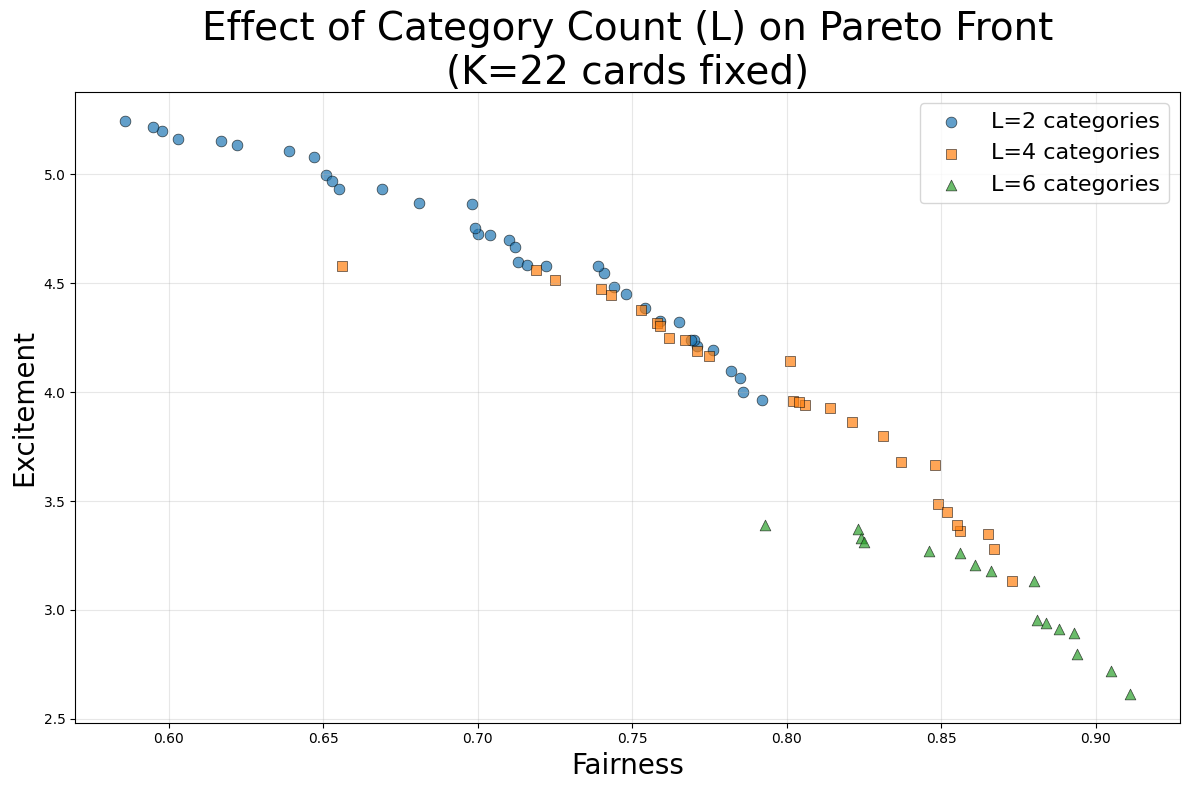

In [33]:
# Compare Pareto fronts for different L values
plot_pareto_comparison(
    [res_k22_l2, res_k22_l4, res_k22_l6],
    ['L=2 categories', 'L=4 categories', 'L=6 categories'],
    title='Effect of Category Count (L) on Pareto Front\n(K=22 cards fixed)'
)

### Effect of Number of Cards (K)

We fix L=4 categories and vary the number of cards K. More cards mean longer games with more tricks, which may lead to different excitement patterns (more opportunities for trick changes) and affect fairness (more samples means skill advantage may be more consistent).

In [12]:
# Run optimizations for different K values (this may take a while)
print("Running optimizations for different card counts (K)...")
print("=" * 50)

res_k16_l4 = run_optimization(K=16, L=4, n_gen=100)
# res_k22_l4 already computed above
res_k28_l4 = run_optimization(K=28, L=4, n_gen=100)

Running optimizations for different card counts (K)...
K=16, L=4: Found 30 Pareto-optimal solutions
K=28, L=4: Found 27 Pareto-optimal solutions


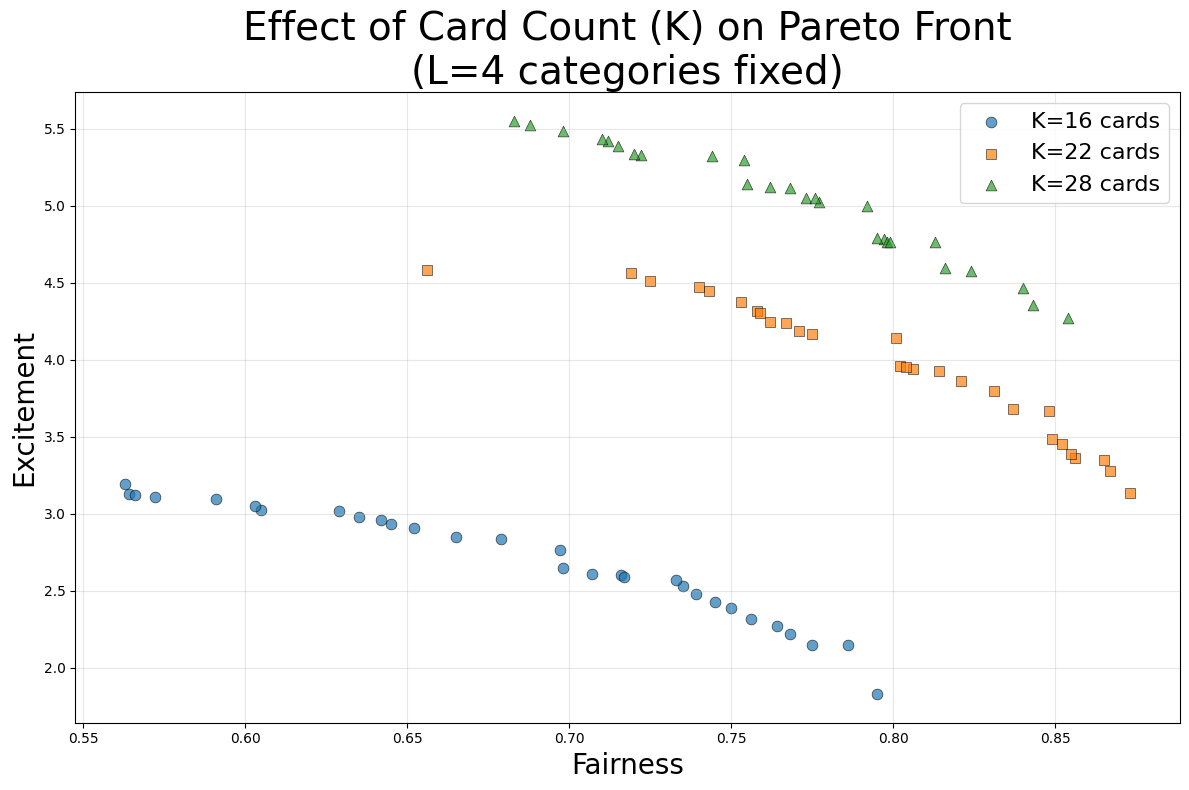

In [31]:
# Compare Pareto fronts for different K values
plot_pareto_comparison(
    [res_k16_l4, res_k22_l4, res_k28_l4],
    ['K=16 cards', 'K=22 cards', 'K=28 cards'],
    title='Effect of Card Count (K) on Pareto Front\n(L=4 categories fixed)'
)